# quick check of the frequency correlation between the Tfh17 and Mem B

In [1]:
# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('tidyverse')
quiet_library('lubridate')
quiet_library('ggplot2')
quiet_library('ggpubr')
quiet_library('lme4')
quiet_library('data.table')

Warning message:
“Failed to locate timezone database”


In [2]:
# define path 
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction'

## load frequency table for T/B mem clusters

In [3]:
# laod the freq table for t cell cluster
T_freq_table = read_csv('/home/workspace/data/ra_longitudinal/revision_work/CD4T_mem_certpro_Frq_clr_res_0_4_freq.csv',
                     show_col_types = FALSE)
# seperate the longitudinal data for c3
c3_freq_table <- T_freq_table %>% filter(clusters=='cluster3'& !is.na(Status_Long))%>%
    rename('Freq_CD4mem' ='frequency_live')%>% filter(days_to_conversion>=(-750))%>% 
    filter(subject.biologicalSex=='Female')

New names:
• `` -> `...1`


In [4]:
c3_freq_table%>%head()

...1,sample.sampleKitGuid,BMI,days_to_conversion,ageAtDraw,subject.biologicalSex,subject.subjectGuid,bmi_conv,age_conv,Status_Long,Status_Xsec,Age2023,anti_ccp3,anti_ccp3_finalCombined,anti_ccp31,clusters,Freq_CD4mem,clr
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
4,KT00052,24.65716,-714,56,Female,CU1009,25.64892,58,pre,at_risk,60,88,88,74,cluster3,0.06872852,0.5683484
42,KT00056,25.94834,-632,42,Female,CU1007,26.19498,44,pre,at_risk,46,262,2544,262,cluster3,0.06352087,0.4718478
61,KT00057,21.12653,-615,21,Female,CU1003,23.14306,23,pre,at_risk,25,262,262,262,cluster3,0.05725355,0.2704493
384,KT00082,25.98790,-540,43,Female,CU1007,26.19498,44,pre,NA,46,262,2901,262,cluster3,0.04831108,0.1868553
403,KT00084,27.61246,-614,65,Female,CU1029,28.67547,66,pre,at_risk,68,42,42,47,cluster3,0.08004456,0.8528524
574,KT00099,21.37006,-516,22,Female,CU1003,23.14306,23,pre,NA,25,262,866,262,cluster3,0.06550580,0.5952823


In [5]:
formula = 'clr ~ age_conv + bmi_conv + days_to_conversion + (days_to_conversion | subject.subjectGuid)'
c3_freq_model =  lmerTest::lmer(c3_freq_table, formula = formula)

boundary (singular) fit: see help('isSingular')



In [6]:
summary(c3_freq_model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula
   Data: c3_freq_table

REML criterion at convergence: 68.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0092 -0.6534 -0.0042  0.6390  2.1767 

Random effects:
 Groups              Name               Variance  Std.Dev.  Corr
 subject.subjectGuid (Intercept)        1.011e-02 0.1005393     
                     days_to_conversion 1.737e-08 0.0001318 1.00
 Residual                               1.181e-01 0.3436366     
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)   
(Intercept)         0.8697015  0.2902480  8.5487824   2.996  0.01593 * 
age_conv           -0.0045615  0.0039766  8.9136265  -1.147  0.28120   
bmi_conv            0.0086257  0.0092739  8.6041566   0.930  0.37767   
days_to_conversion  0.0007382  0.0002231 32.3111978   3.309  0.00231 **
---
Signif. codes:  0 ‘***’ 0.

In [7]:
random_effects <- ranef(c3_freq_model)$subject.subjectGuid
# extract the indiviudal slopes
fixed_effect_slope <- fixef(c3_freq_model)["days_to_conversion"]
individual_slopes_values <- fixed_effect_slope + random_effects[,"days_to_conversion"]
# individual slopes
individual_slopes_c3 = tibble(subject=rownames(random_effects),
                           individual_slopes_c3 = individual_slopes_values)
individual_slopes_c3

subject,individual_slopes_c3
<chr>,<dbl>
CU1003,0.0007407572
CU1007,0.0007399319
CU1009,0.0007637942
CU1010,0.0007201541
CU1029,0.0006934604
CU1033,0.0007011028
CU1037,0.0007503182
CU1039,0.0007264535
CU1050,0.0007567517


In [8]:
# check the relationship with ccp3
max_ccp3 = c3_freq_table %>% filter(!is.na(anti_ccp3_finalCombined))%>% 
    group_by(subject.subjectGuid)%>%
    summarise(max_ccp3 = max(anti_ccp3_finalCombined))%>% ungroup()%>%
    rename('subject'='subject.subjectGuid')

individual_slopes_c3 = individual_slopes_c3%>%left_join(max_ccp3, by='subject')

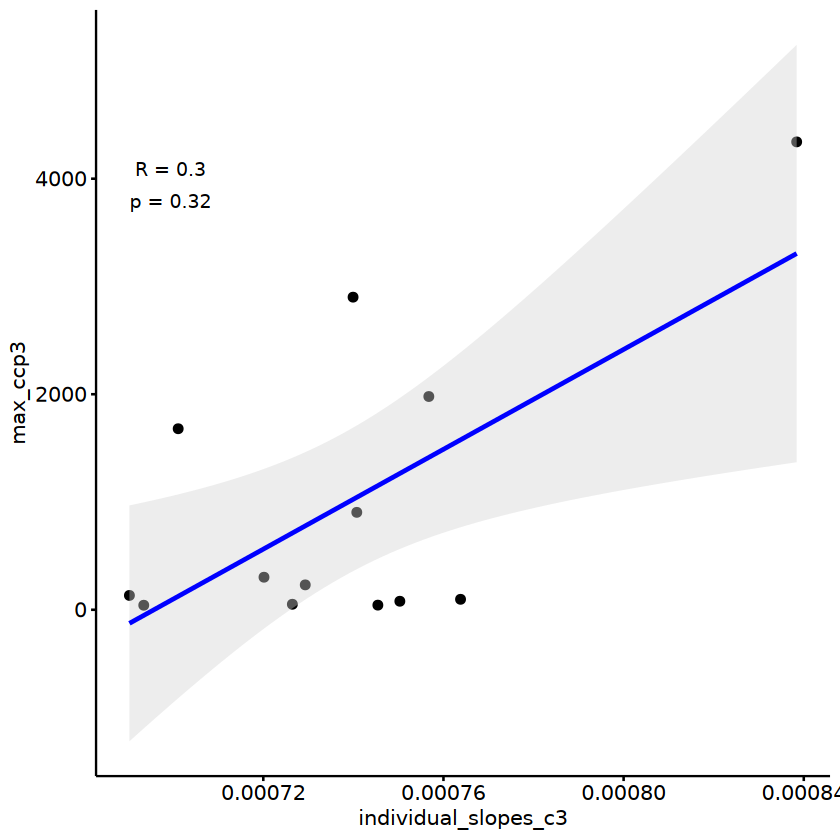

In [9]:
ggscatter(individual_slopes_c3, x='individual_slopes_c3', y='max_ccp3',
                              add = "reg.line",  # Add regressin line
   add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
   conf.int = TRUE, # Add confidence interval
   cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
   cor.coeff.args = list(method = "spearman", label.sep = "\n"))

## import B mem cells

In [10]:
bmem_freq = readxl::read_excel('/home/workspace/data/ra_longitudinal/output_results/Bmem/Table_S21_Beffector_cluster_frequency.xlsx')

In [11]:
bc9_freq <- bmem_freq%>%filter(cell_type==9)%>%mutate(scale_dtc = scale(days_to_conversion)) %>% filter(
          subject.biologicalSex=='Female')
bc9_freq

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,days_to_conversion,status,file.batchID,Status_Long,age_conv,⋯,total_b_counts,counts,bmem_counts,b_frequency,pseudo_count,pseudo_b_counts,pseudo_b_frequency,bmem_freq,clr,scale_dtc
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>"
KT00052,9,0.004761905,CU1009,Female,-714,at_risk,B140,pre,58,⋯,1432,2,420,0.001396648,3,1445,0.002076125,0.004761905,-2.129081957,-1.92746829
KT00056,9,0.042462845,CU1007,Female,-632,at_risk,B002,pre,44,⋯,1136,20,471,0.017605634,21,1149,0.018276762,0.042462845,-0.368677606,-1.56121828
KT00057,9,0.019955654,CU1003,Female,-615,at_risk,B002,pre,23,⋯,970,9,451,0.009278351,10,983,0.010172940,0.019955654,-0.888143619,-1.48528839
KT00082,9,0.035580524,CU1007,Female,-540,at_risk,B005,pre,44,⋯,1665,19,534,0.011411411,20,1678,0.011918951,0.035580524,-0.417710622,-1.15030363
KT00084,9,0.064039409,CU1029,Female,-614,at_risk,B010,pre,66,⋯,1587,39,609,0.024574669,40,1600,0.025000000,0.064039409,0.063705463,-1.48082193
KT00099,9,0.042307692,CU1003,Female,-516,at_risk,B005,pre,23,⋯,1762,22,520,0.012485812,23,1775,0.012957746,0.042307692,-0.151739021,-1.04310850
KT00103,9,0.056847545,SD1003,Female,-80,at_risk,B046,pre,36,⋯,2989,22,387,0.007360321,23,3002,0.007661559,0.056847545,-0.311180309,0.90426962
KT00105,9,0.015025042,SD1007,Female,-92,at_risk,B070,pre,32,⋯,2408,9,599,0.003737542,10,2421,0.004130525,0.015025042,-1.170271591,0.85067205
KT00109,9,0.057017544,SD1003,Female,0,conversion,B046,conversion,36,⋯,2661,13,228,0.004885381,14,2674,0.005235602,0.057017544,-0.402204171,1.26158670


In [12]:
# test the model in c9
formula_linear1 <- as.formula("clr ~ age_conv + bmi_conv + days_to_conversion + (days_to_conversion |subject.subjectGuid)")

c9_fit <- lmerTest::lmer(formula = formula_linear1,
                         data = bc9_freq %>% filter(
          subject.biologicalSex=='Female'))
summary(c9_fit)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0320193 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: bc9_freq %>% filter(subject.biologicalSex == "Female")

REML criterion at convergence: 108.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.50107 -0.53059 -0.01409  0.42824  2.08287 

Random effects:
 Groups              Name               Variance  Std.Dev.  Corr 
 subject.subjectGuid (Intercept)        2.763e-01 0.5256779      
                     days_to_conversion 6.087e-07 0.0007802 -0.78
 Residual                               1.619e-01 0.4024024      
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)  
(Intercept)        -1.9834496  0.9790225  6.0705397  -2.026   0.0886 .
age_conv            0.0090572  0.0136122  6.7138782   0.665   0.5280  
bmi_conv            0.0407502  0.0321167  6.0827830   1.269   0.2509  
days_to_conversion  0.0004732  0.0003970  

In [13]:
random_effects <- ranef(c9_fit)$subject.subjectGuid
# extract the indiviudal slopes
fixed_effect_slope <- fixef(c9_fit)["days_to_conversion"]
individual_slopes_values <- fixed_effect_slope + random_effects[,"days_to_conversion"]
# individual slopes
individual_slopes_b = tibble(subject=rownames(random_effects),
                           individual_slopes_c9 = individual_slopes_values)
individual_slopes_b

subject,individual_slopes_c9
<chr>,<dbl>
CU1003,1.022576e-04
CU1007,2.253200e-04
CU1009,1.218682e-03
CU1010,1.510212e-03
CU1029,2.525210e-04
CU1033,4.724329e-04
CU1037,1.187888e-03
CU1039,-2.487619e-04
CU1050,-6.200846e-04


In [14]:
individual_slopes = individual_slopes_c3%>%left_join(individual_slopes_b, by='subject')
individual_slopes

subject,individual_slopes_c3,max_ccp3,individual_slopes_c9
<chr>,<dbl>,<dbl>,<dbl>
CU1003,0.0007407572,904,1.022576e-04
CU1007,0.0007399319,2901,2.253200e-04
CU1009,0.0007637942,97,1.218682e-03
CU1010,0.0007201541,302,1.510212e-03
CU1029,0.0006934604,42,2.525210e-04
CU1033,0.0007011028,1680,4.724329e-04
CU1037,0.0007503182,79,1.187888e-03
CU1039,0.0007264535,51,-2.487619e-04
CU1050,0.0007567517,1979,-6.200846e-04


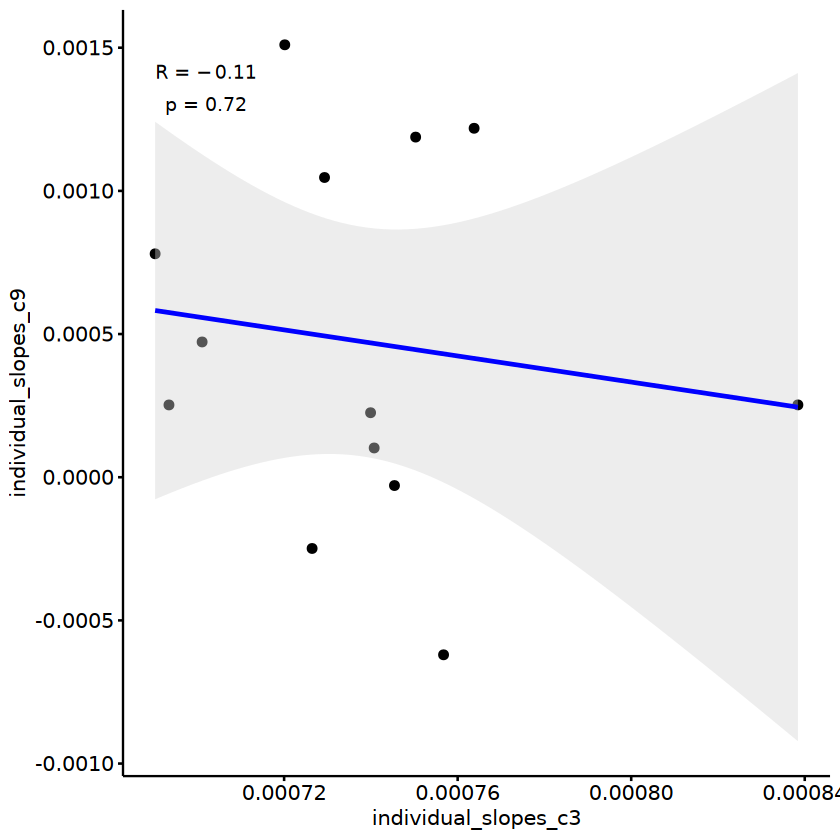

In [15]:
ggscatter(individual_slopes, x='individual_slopes_c3', y='individual_slopes_c9',
                              add = "reg.line",  # Add regressin line
   add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
   conf.int = TRUE, # Add confidence interval
   cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
   cor.coeff.args = list(method = "spearman",  label.sep = "\n"))

In [16]:
# plot the frequency
c3_c9_freq_table <- c3_freq_table%>%select(c(sample.sampleKitGuid, subject.subjectGuid, clusters, Freq_CD4mem, clr))%>%
    left_join(select(bc9_freq, c(sample.sampleKitGuid, bmem_freq, clr)), by = 'sample.sampleKitGuid', 
              suffix = c('_c3', '_c9'))
c3_c9_freq_table%>%head()

sample.sampleKitGuid,subject.subjectGuid,clusters,Freq_CD4mem,clr_c3,bmem_freq,clr_c9
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
KT00052,CU1009,cluster3,0.06872852,0.5683484,0.004761905,-2.12908196
KT00056,CU1007,cluster3,0.06352087,0.4718478,0.042462845,-0.36867761
KT00057,CU1003,cluster3,0.05725355,0.2704493,0.019955654,-0.88814362
KT00082,CU1007,cluster3,0.04831108,0.1868553,0.035580524,-0.41771062
KT00084,CU1029,cluster3,0.08004456,0.8528524,0.064039409,0.06370546
KT00099,CU1003,cluster3,0.06550580,0.5952823,0.042307692,-0.15173902


In [17]:
fig_path

[1] "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures"

Saving 6.67 x 6.67 in image


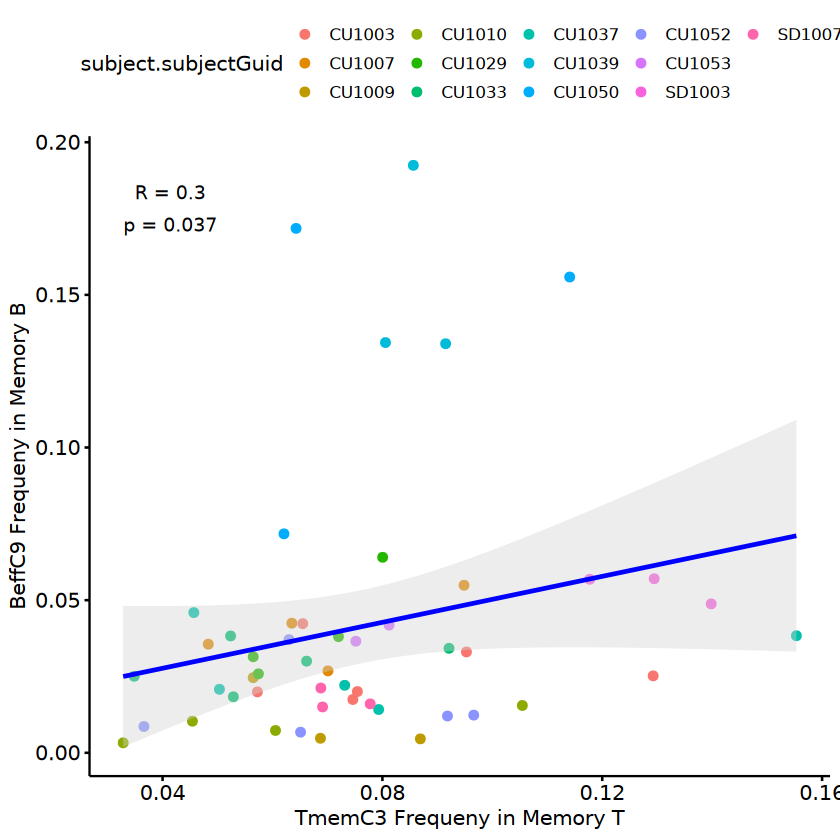

In [24]:
p1 = ggscatter(c3_c9_freq_table, x='Freq_CD4mem', y='bmem_freq', color = 'subject.subjectGuid',
                              add = "reg.line",  # Add regressin line
                  xlab = 'TmemC3 Frequeny in Memory T',
               ylab = 'BeffC9 Frequeny in Memory B',
   add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
   conf.int = TRUE, # Add confidence interval
   cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
   cor.coeff.args = list(method = "spearman",  label.sep = "\n"))
p1
ggsave(file.path(fig_path, 'ALTRA_Tc3_Bc9_correlation.png'))

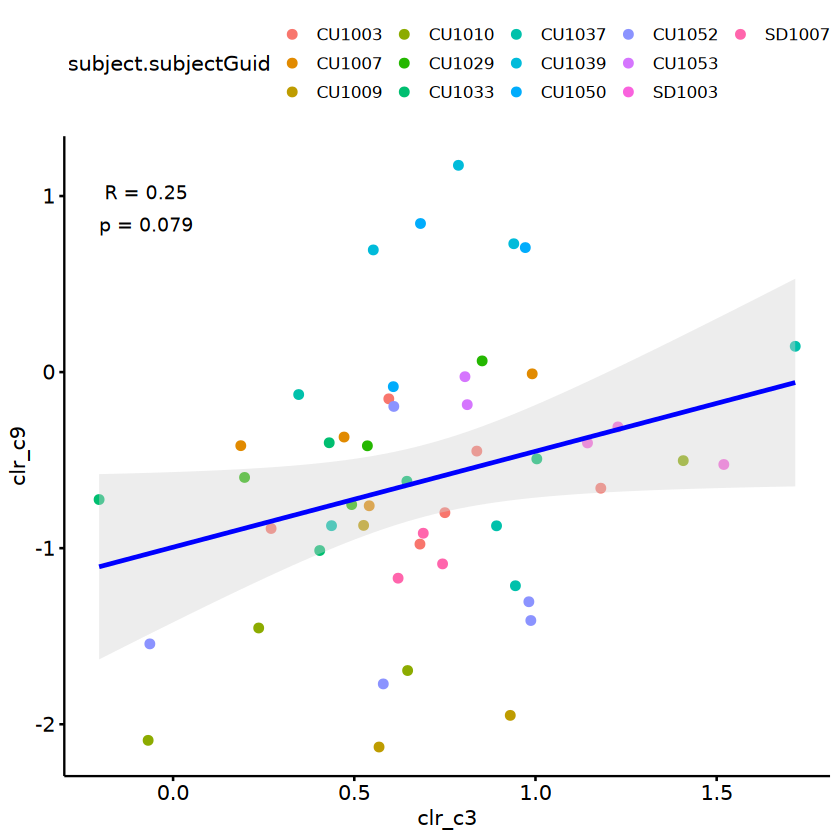

In [19]:
p2 = ggscatter(c3_c9_freq_table, x='clr_c3', y='clr_c9', color = 'subject.subjectGuid',
                              add = "reg.line",  # Add regressin line
   add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
   conf.int = TRUE, # Add confidence interval
   cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
   cor.coeff.args = list(method = "spearman",  label.sep = "\n"))
p2

In [20]:
# plot frequency for C8 
# plot the frequency
bc8_freq <- bmem_freq%>%filter(cell_type==8)%>%mutate(scale_dtc = scale(days_to_conversion)) %>% filter(
          subject.biologicalSex=='Female')

c3_c8_freq_table <- c3_freq_table%>%select(c(sample.sampleKitGuid, subject.subjectGuid, clusters, Freq_CD4mem, clr))%>%
    left_join(select(
        bc8_freq, c(sample.sampleKitGuid, bmem_freq, clr)), by = 'sample.sampleKitGuid', 
              suffix = c('_c3', '_c8'))
c3_c8_freq_table%>%head()

sample.sampleKitGuid,subject.subjectGuid,clusters,Freq_CD4mem,clr_c3,bmem_freq,clr_c8
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
KT00052,CU1009,cluster3,0.06872852,0.5683484,0.04523810,-0.2319620
KT00056,CU1007,cluster3,0.06352087,0.4718478,0.02760085,-0.7741427
KT00057,CU1003,cluster3,0.05725355,0.2704493,0.01552106,-1.1112872
KT00082,CU1007,cluster3,0.04831108,0.1868553,0.01685393,-1.1108578
KT00084,CU1029,cluster3,0.08004456,0.8528524,0.07224959,0.1814885
KT00099,CU1003,cluster3,0.06550580,0.5952823,0.01538462,-1.0900087


Saving 6.67 x 6.67 in image


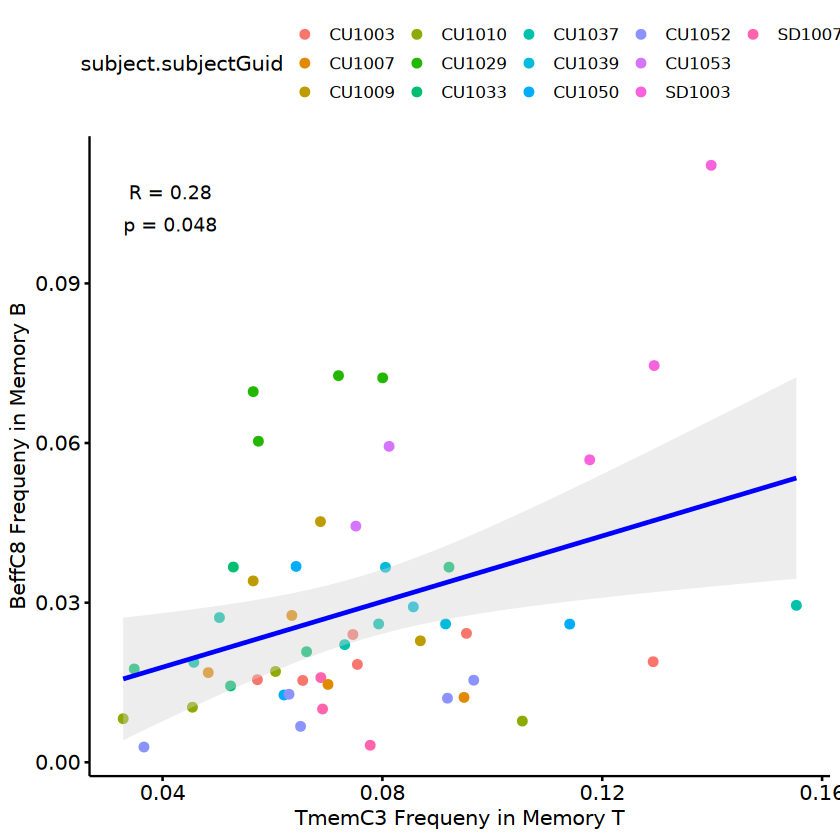

In [23]:
p1 = ggscatter(c3_c8_freq_table, x='Freq_CD4mem', y='bmem_freq', color = 'subject.subjectGuid',
               xlab = 'TmemC3 Frequeny in Memory T',
               ylab = 'BeffC8 Frequeny in Memory B',
                              add = "reg.line",  # Add regressin line
   add.params = list(color = "blue", fill = "lightgray"), # Customize reg. line
   conf.int = TRUE, # Add confidence interval
   cor.coef = TRUE, # Add correlation coefficient. see ?stat_cor
   cor.coeff.args = list(method = "spearman",  label.sep = "\n"))
p1
ggsave(file.path(fig_path, 'ALTRA_Tc3_Bc8_correlation.png'))